In [1]:
# Homework 3 code

import cv2 as cv
import numpy as np
import os
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

In [16]:
DATA_PATH = "Fish"

dataset = keras.utils.image_dataset_from_directory(
    directory=DATA_PATH,
    validation_split=0.30,
    subset="both",
    seed=67,
    image_size=(128, 128), # Part 2 req
    batch_size=32
)


Found 1016 files belonging to 6 classes.
Using 712 files for training.
Using 304 files for validation.


In [21]:
train_set = dataset[0]
remaining = dataset[1]

# remaining has 30% so cutting it into 2
remaining_set = tf.data.experimental.cardinality(remaining)

val_set = remaining.take(remaining_set // 2)
test_set = remaining.skip(remaining_set // 2)


In [65]:
class_names = train_set.class_names

In [26]:
from keras import layers

data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(.2),
    layers.RandomBrightness(.3)
])

In [33]:
model = keras.Sequential([
    data_aug,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:
history = model.fit(
    train_set,
    validation_data=val_set,
    epochs=25
)

Epoch 1/25


/Users/minhtran/Desktop/College stuff/9th Semester (Summer 2026)/Computer Vision Project/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-07-17 21:37:26.771800: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.3399 - loss: 1.6598 - val_accuracy: 0.4437 - val_loss: 1.7776
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5042 - loss: 1.3570 - val_accuracy: 0.5562 - val_loss: 1.3192
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.5449 - loss: 1.2122 - val_accuracy: 0.5750 - val_loss: 1.2042
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6180 - loss: 1.0268 - val_accuracy: 0.6375 - val_loss: 0.9761
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6376 - loss: 0.9712 - val_accuracy: 0.6562 - val_loss: 0.8567
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6587 - loss: 0.9239 - val_accuracy: 0.7000 - val_loss: 0.8392
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7079 - loss: 0.8215 - val_accuracy: 0.6687 - val_loss: 0.9758
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7402 - loss: 0.6716 - val_accuracy: 0.7250 - val_loss: 0.

In [36]:
model.save("baseline.keras")

In [37]:
test_loss, test_acc = model.evaluate(test_set)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.8681 - loss: 0.6000


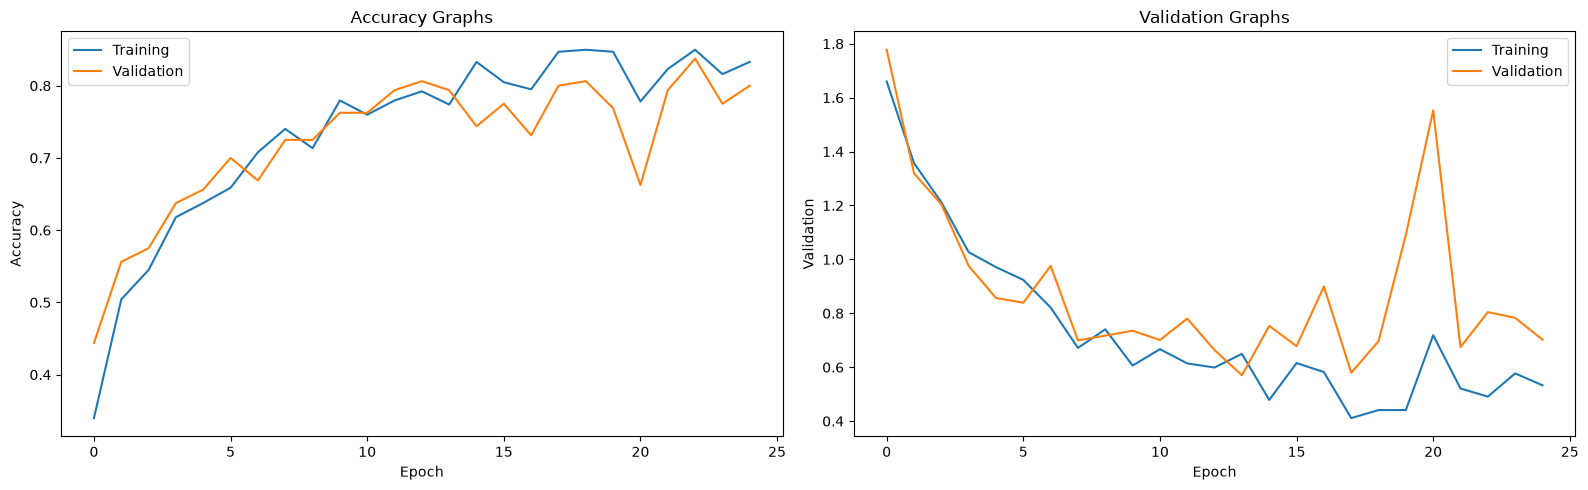

In [58]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy Graphs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation")
plt.title("Validation Graphs")

plt.tight_layout()
plt.show()

In [59]:
# helper funcs for the grid search

def dataset(batch_size, path):
    dataset = keras.utils.image_dataset_from_directory(
        directory=path,
        validation_split=0.30,
        subset="both",
        seed=67,
        image_size=(128, 128),
        batch_size=batch_size
    )
    train_set = dataset[0]
    remaining = dataset[1]
    remaining_set = tf.data.experimental.cardinality(remaining)
    val_set = remaining.take(remaining_set // 2)
    test_set = remaining.skip(remaining_set // 2)

    return train_set, val_set, test_set

def model(dropout, data_aug):
    model = keras.Sequential([
        data_aug,
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dropout(dropout),
        layers.Dense(128, activation='relu'),
        layers.Dense(6, activation='softmax')
    ])
    return model

In [75]:
# Part 4

learning_rates = [0.01, 0.001, 0.0001]
batch_sizes = [32, 64]
dropouts = [0.3, 0.5]

best_val_acc = 0
best_history = None
best_params = None
best_model = None

model_history = []

for learning_rate in learning_rates:
    for batch_size in batch_sizes:
        for dropout in dropouts:
            train_set, val_set, test_set = dataset(batch_size, DATA_PATH)
            grid_model = model(dropout, data_aug)

            grid_model.compile(
                optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"]
            )

            history = grid_model.fit(
                train_set,
                validation_data=val_set,
                epochs=25
            )

            val_acc = max(history.history["val_accuracy"])
            params = (learning_rate, batch_size, dropout)
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_history = history
                best_params = params
                best_model = grid_model

            model_history.append((params, val_acc))

            

best_model.save("best_model.keras")

Found 1016 files belonging to 6 classes.
Using 712 files for training.
Using 304 files for validation.
Epoch 1/25


/Users/minhtran/Desktop/College stuff/9th Semester (Summer 2026)/Computer Vision Project/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.1896 - loss: 4.3866 - val_accuracy: 0.1875 - val_loss: 2.5958
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.1966 - loss: 2.2233 - val_accuracy: 0.2250 - val_loss: 2.1020
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.1615 - loss: 1.9056 - val_accuracy: 0.1813 - val_loss: 1.7832
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.1966 - loss: 1.7924 - val_accuracy: 0.2250 - val_loss: 1.7682
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.1882 - loss: 1.7921 - val_accuracy: 0.1813 - val_loss: 1.7676
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.1756 - loss: 1.7664 - val_accuracy: 0.1813 - val_loss: 1.7613
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.1826 - loss: 1.7717 - val_accuracy: 0.1813 - val_loss: 1.7654
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.1910 - loss: 1.7648 - val_accuracy: 0.1813 - val_loss: 1.

Found 1016 files belonging to 6 classes.
Using 712 files for training.
Using 304 files for validation.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
              precision    recall  f1-score   support

        Bete       0.75      0.86      0.80        35
        Cray       0.50      0.75      0.60         4
     Discuss       0.90      0.84      0.87        31
        Gold       1.00      0.82      0.90        33
       Guppy       0.96      0.96      0.96        25
       Oscar       0.59      0.62      0.61        16

    accuracy                           0.83       144
   macro avg       0.78      0.81      0.79       144
weighted avg       0.85      0.83      0.84       144



2026-07-18 00:35:01.124866: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


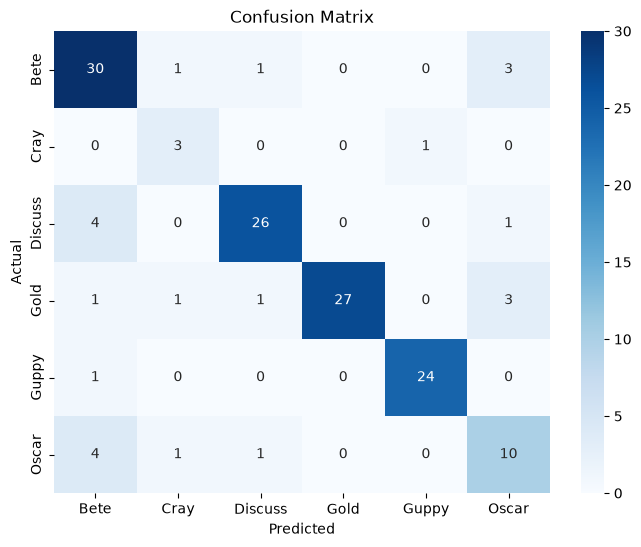

In [76]:
# Part 5

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

best_batch = best_params[1]
grid_train_ds, grid_val_ds, grid_test_ds = dataset(best_batch, DATA_PATH)

pred = best_model.predict(grid_test_ds)

y_pred = np.argmax(pred, axis=1)

y_true = np.concatenate([y for x, y in grid_test_ds])


print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

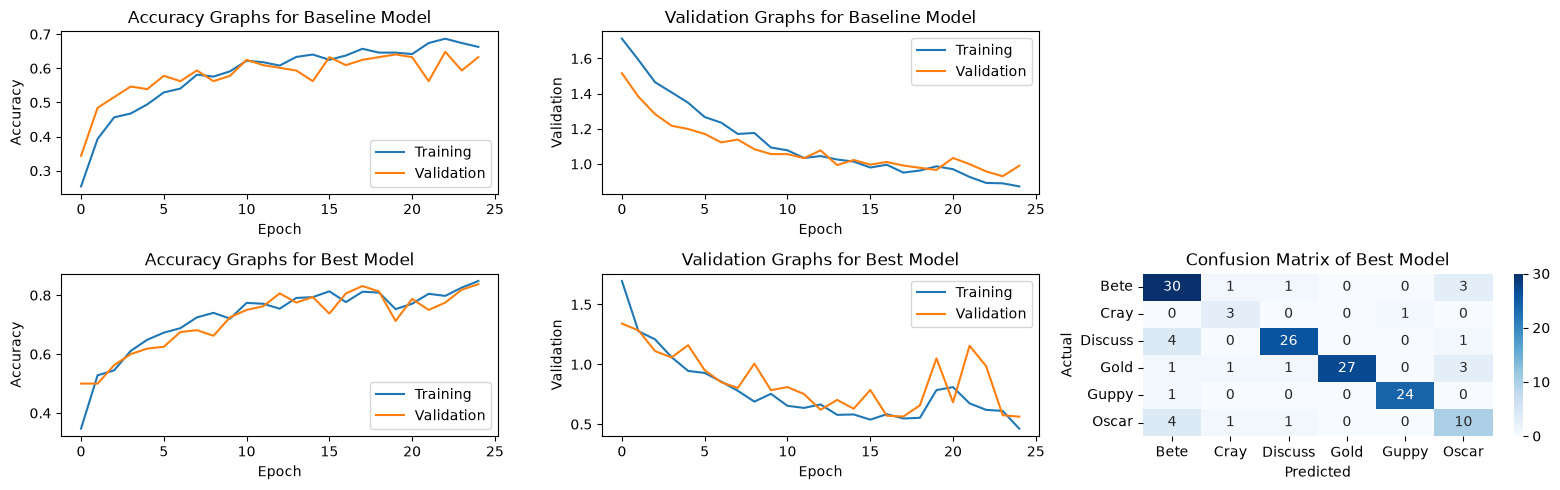

In [77]:
plt.figure(figsize=(16,5))

#baseline
plt.subplot(2,3,1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy Graphs for Baseline Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(2,3,2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation")
plt.title("Validation Graphs for Baseline Model")

#confusion matrix
plt.subplot(2,3,6)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix of Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

#best

plt.subplot(2,3,4)
plt.plot(best_history.history["accuracy"], label="Training")
plt.plot(best_history.history["val_accuracy"], label="Validation")
plt.title("Accuracy Graphs for Best Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(2,3,5)
plt.plot(best_history.history["loss"], label="Training")
plt.plot(best_history.history["val_loss"], label="Validation")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation")
plt.title("Validation Graphs for Best Model")

plt.tight_layout()
plt.show()

In [90]:
print(best_params, val_acc)

for model_ in model_history:
    print(f"Learning Rate: {model_[0][0]} | Batch Size: {model_[0][1]}| Dropout: {model_[0][2]} | val accuracy: {model_[1]:.4f}")

(0.001, 32, 0.3) 0.6484375
Learning Rate: 0.01 | Batch Size: 32| Dropout: 0.3 | val accuracy: 0.2250
Learning Rate: 0.01 | Batch Size: 32| Dropout: 0.5 | val accuracy: 0.2250
Learning Rate: 0.01 | Batch Size: 64| Dropout: 0.3 | val accuracy: 0.5703
Learning Rate: 0.01 | Batch Size: 64| Dropout: 0.5 | val accuracy: 0.5938
Learning Rate: 0.001 | Batch Size: 32| Dropout: 0.3 | val accuracy: 0.8375
Learning Rate: 0.001 | Batch Size: 32| Dropout: 0.5 | val accuracy: 0.7812
Learning Rate: 0.001 | Batch Size: 64| Dropout: 0.3 | val accuracy: 0.8359
Learning Rate: 0.001 | Batch Size: 64| Dropout: 0.5 | val accuracy: 0.8203
Learning Rate: 0.0001 | Batch Size: 32| Dropout: 0.3 | val accuracy: 0.7063
Learning Rate: 0.0001 | Batch Size: 32| Dropout: 0.5 | val accuracy: 0.7188
Learning Rate: 0.0001 | Batch Size: 64| Dropout: 0.3 | val accuracy: 0.6641
Learning Rate: 0.0001 | Batch Size: 64| Dropout: 0.5 | val accuracy: 0.6484
